# Assignment 1: (Classification of Seizure using Machine Learning Classifiers and EEG Data)
---
---

## Task 1: Problem setup, data loading, and cleaning (3 marks)
---

### a.Import useful Libraries:

In [1]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


### b. Read the CSV files using pandas and check its structure

In [3]:

# Load the CSV files
train_df = pd.read_csv("./Datasets/EEG_Train_Binary.csv")
test_df = pd.read_csv("./Datasets/EEG_Test_Binary.csv")

#Print the shape of the data
print("Train shape: ", train_df.shape)
print("Test shape: ", test_df.shape)
print("Train-Test percentage: Train ", round(train_df.shape[0]/(train_df.shape[0]+test_df.shape[0]), 2)*100, "% - Test ", round(test_df.shape[0]/(train_df.shape[0]+test_df.shape[0]), 2)*100, "%")
#So there are 17 features out of which the last one is the target

Train shape:  (3171, 17)
Test shape:  (829, 17)
Train-Test percentage: Train  79.0 % - Test  21.0 %


In [205]:
# Inspect the data:
print("Train data structure: \n", train_df.head(3))

Train data structure: 
     X1   X2   X3  X4  X5   X6   X7   X8   X9  X10  X11  X12  X13  X14  X15  \
0   41   32  -27 -51 -89 -117  -83  -35   25   33   27   33   -9  -38  -57   
1 -281 -234 -166 -93 -22   55  109  137  115   80   54   50   37   -3  -53   
2    2   -1  -11 -32 -44  -44  -35  -23   -8   -7  -14  -15   -2   17   19   

   X16  y  
0  -87  0  
1 -111  0  
2    7  0  


In [206]:
# Information about the data
print("Train data information: ", train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3171 entries, 0 to 3170
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      3171 non-null   int64
 1   X2      3171 non-null   int64
 2   X3      3171 non-null   int64
 3   X4      3171 non-null   int64
 4   X5      3171 non-null   int64
 5   X6      3171 non-null   int64
 6   X7      3171 non-null   int64
 7   X8      3171 non-null   int64
 8   X9      3171 non-null   int64
 9   X10     3171 non-null   int64
 10  X11     3171 non-null   int64
 11  X12     3171 non-null   int64
 12  X13     3171 non-null   int64
 13  X14     3171 non-null   int64
 14  X15     3171 non-null   int64
 15  X16     3171 non-null   int64
 16  y       3171 non-null   int64
dtypes: int64(17)
memory usage: 421.3 KB
Train data information:  None


### c. Division of data into Features and Target

In [207]:
# Define the target variable and seperate the features from the target
target = "y"

feature_train = train_df.drop(columns = [target])
target_train = train_df[target]
feature_test = test_df.drop(columns = [target])
target_test = test_df[target]
print(feature_train.values.min())
print(feature_train.values.max())
print(feature_test.values.min())
print(feature_test.values.max())

-323
296
-306
280


### d. Filling up the missing values, if any, with the mean values.

In [208]:
# Fill missing numeric values with mean (Didn't find any missing values)
def fill_missing_values(data, fn):
    return data.apply(fn)

train_mean = fill_missing_values(feature_train, "mean")
feature_train = feature_train.fillna(train_mean)
test_mean = fill_missing_values(feature_test, "mean")
feature_test = feature_test.fillna(test_mean)


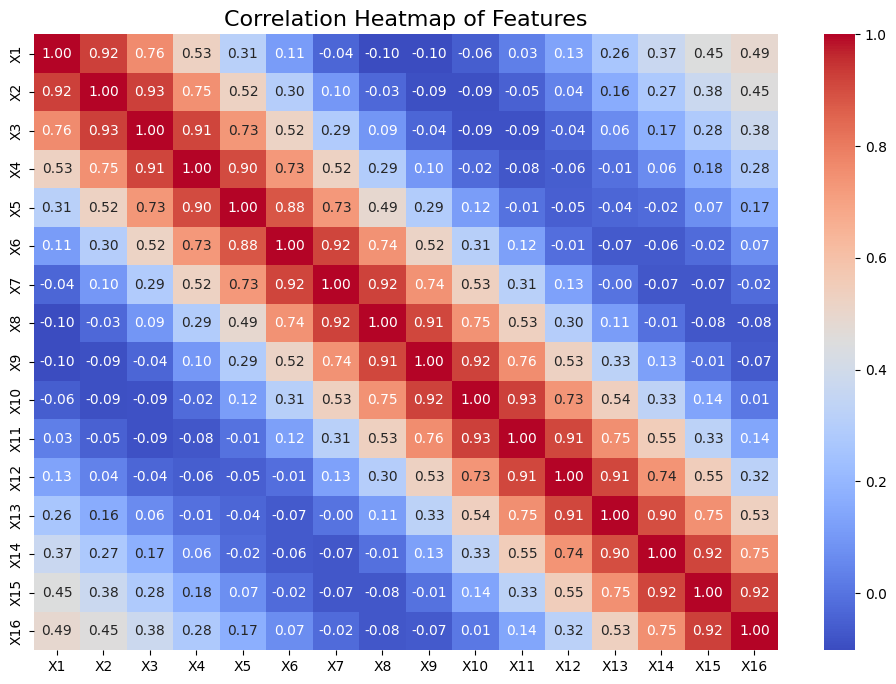

In [209]:
feat_corr = feature_train.corr()
plt.figure(figsize=(12,8))
sns.heatmap(feat_corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)

plt.title("Correlation Heatmap of Features", fontsize=16)
plt.show()

## Task 2: Decision Trees: Gini, Information Gain, Gain Ratio (6 marks)
---

### Evaluation of max-depth using Decision Tree and picking out the suitable one.

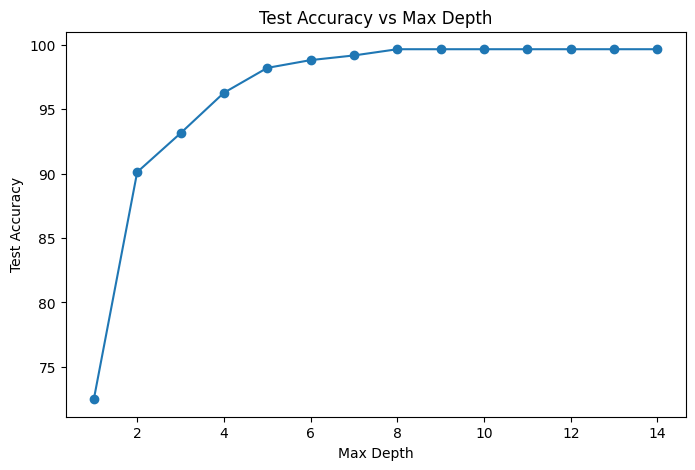

In [210]:
def test_max_depth(d):
    max_d_gini = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=d)
    max_d_gini.fit(feature_train, target_train)
    test_pred = max_d_gini.predict(feature_test)
    gini_test_acc = round(accuracy_score(target_test, test_pred) * 100, 4)
    return gini_test_acc

# Gini Accuracy
test_acc_list = [test_max_depth(i) for i in range(1, 15)]
plt.figure(figsize=(8,5))
plt.plot([i for i in range(1, 15)], test_acc_list, marker="o")
plt.title("Test Accuracy vs Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Test Accuracy")
plt.show()

### a.Train and Test accuracy using Gini:

In [211]:
# Decision Tree using Gini as criterion:
dt_gini = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=6)
dt_gini.fit(feature_train, target_train)

# Gini Predictions
train_pred = dt_gini.predict(feature_train)
test_pred = dt_gini.predict(feature_test)

# Gini Accuracy
gini_train_acc = round(accuracy_score(target_train, train_pred) * 100, 4)
gini_test_acc = round(accuracy_score(target_test, test_pred) * 100, 4)

print("Train Accuracy:", gini_train_acc, "%")
print("Test Accuracy:", gini_test_acc, "%")

Train Accuracy: 99.6531 %
Test Accuracy: 99.035 %


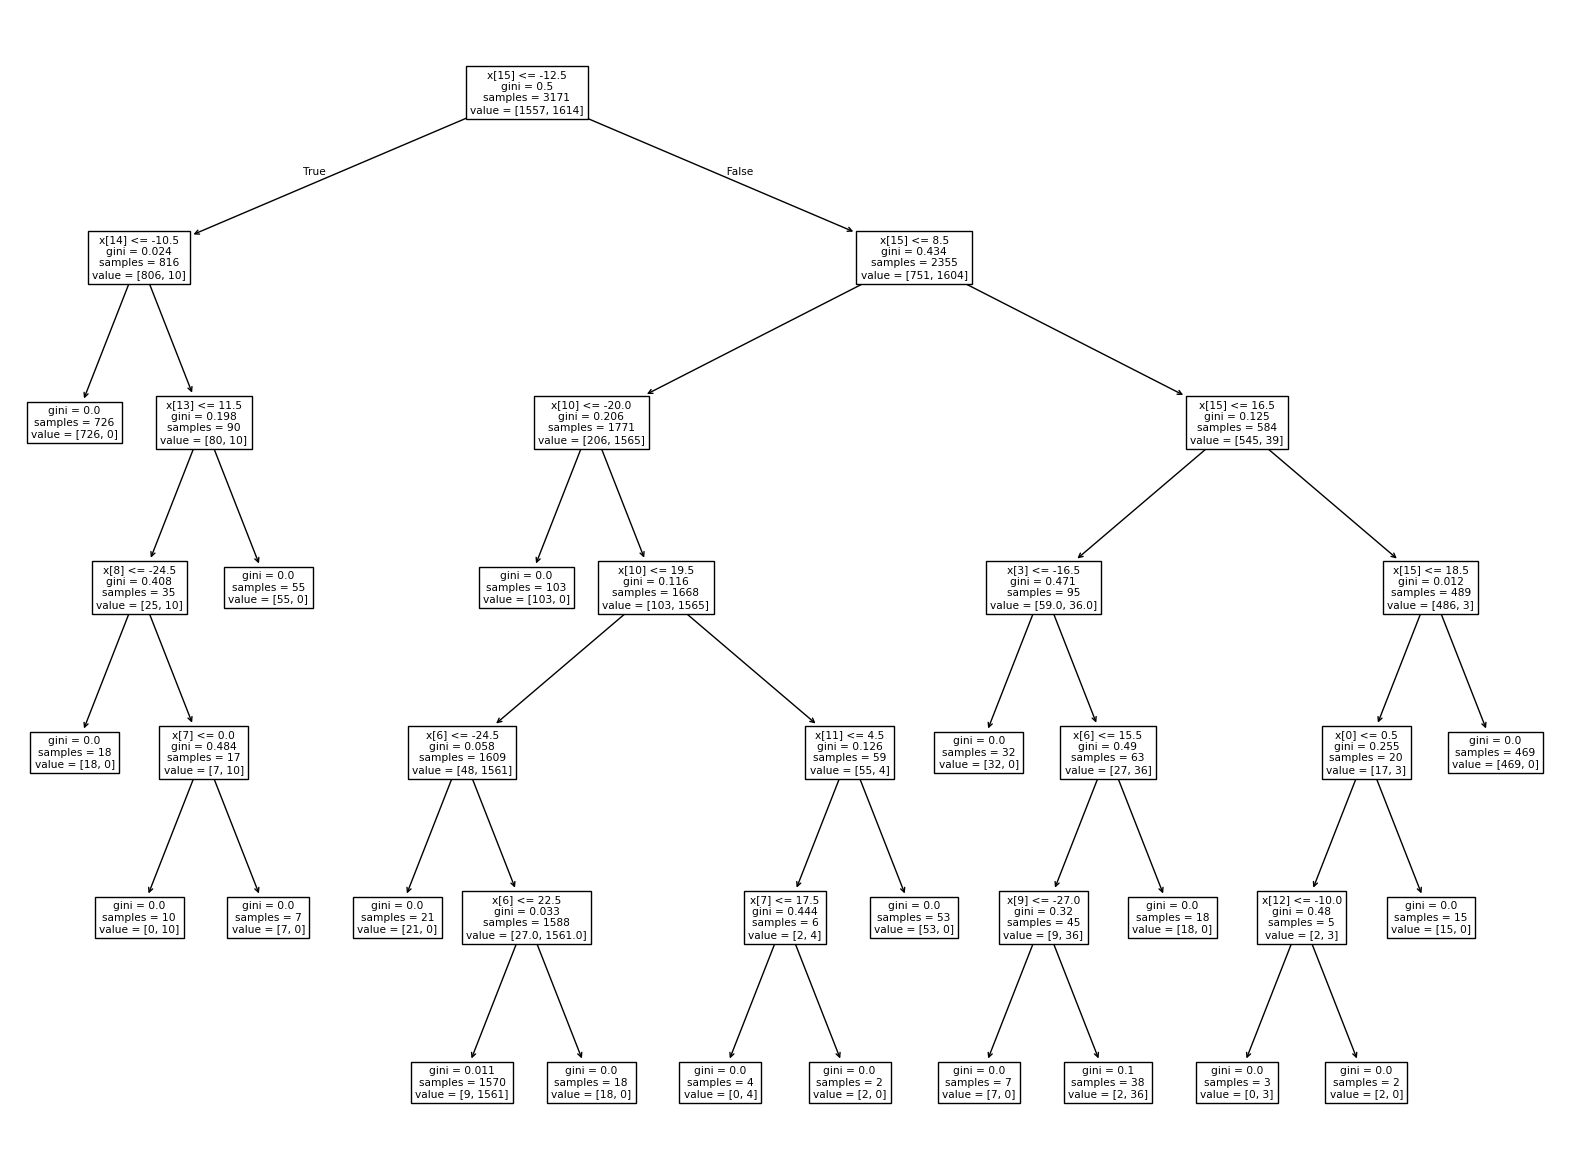

In [212]:
plt.figure(figsize=(20,15))
plot_tree(dt_gini)
plt.show()

### b.Train and Test accuracy using Information Gain (Entropy):

In [213]:
# Decision Tree using entropy as criterion based on Information Gain:
dt_IF = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=6)
dt_IF.fit(feature_train, target_train)

# Information Gain Predictions
train_pred = dt_IF.predict(feature_train)
test_pred = dt_IF.predict(feature_test)

# Information Gain Accuracy
IF_train_acc = round(accuracy_score(target_train, train_pred) * 100, 4)
IF_test_acc = round(accuracy_score(target_test, test_pred) * 100, 4)

print("Train Accuracy:", IF_train_acc, "%")
print("Test Accuracy:", IF_test_acc, "%")

Train Accuracy: 99.59 %
Test Accuracy: 98.7937 %


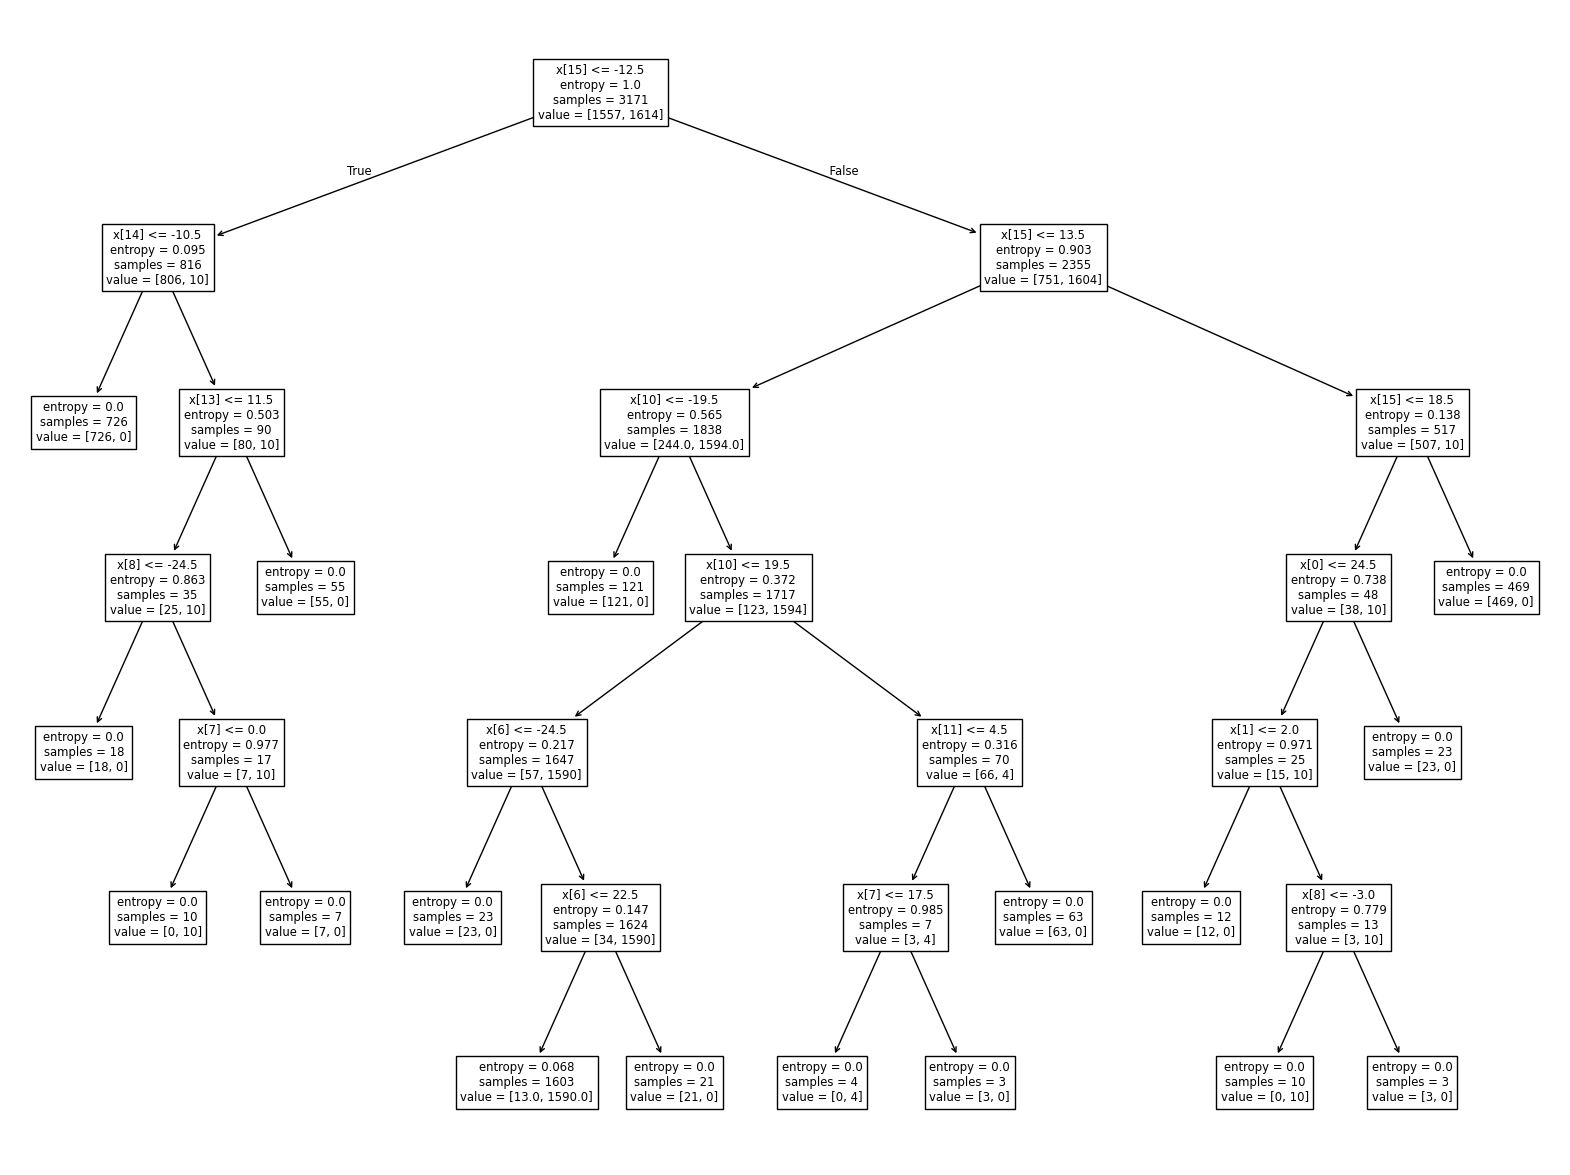

In [214]:
plt.figure(figsize=(20,15))
plot_tree(dt_IF)
plt.show()

In [ ]:
%pip install c45-decision-tree

In [216]:
from C45 import C45Classifier
import pandas as pd

model = C45Classifier()
model.fit(feature_train, target_train)

In [ ]:
model.predict(feature_test)
model.evaluate(feature_test, target_test)

Evaluation result: 
Total accuracy:  0.8094089264173703
Accuracy  0 :  0.6884875846501128
Accuracy  1 :  0.9481865284974094
Test Accuracy: None %


### c.1 Train and Test accuracy using Information Gain Ratio:

In [234]:
# Decision Tree using entropy as criterion based on Gain Ratio:

# Entropy:
def entropy(target_col):
    values, counts = np.unique(target_col, return_counts=True)
    probabilities = counts / counts.sum()
    return -np.sum([p * np.log2(p) for p in probabilities if p > 0])

# Information Gain:
def information_gain(feature, target):
    # Entropy before split
    total_entropy = entropy(target)
    # Weighted entropy for subsets
    values, counts = np.unique(feature, return_counts=True)
    weighted_entropy = 0
    for v, count in zip(values, counts):
        subset = target[feature == v]
        weighted_entropy += (count / len(target)) * entropy(subset)
    
    # Information Gain
    return total_entropy - weighted_entropy

# Gain Ratio:
def gain_ratio(feature, target):
    ig = information_gain(feature, target)
    si = entropy(feature)
    return ig / si if si != 0 else 0

gain_ratios = {}
for x in feature_train.columns:
    gain_ratios[x] = gain_ratio(feature_train[x], target_train)

best_feature_gr = max(gain_ratios, key=gain_ratios.get)

dt_gr = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=6)
dt_gr.fit(feature_train[[best_feature_gr]], target_train)

# Gain Ratio Predictions
train_pred = dt_gr.predict(feature_train[[best_feature_gr]])
test_pred = dt_gr.predict(feature_test[[best_feature_gr]])

# Gain Ratio Accuracy
gr_train_acc = round(accuracy_score(target_train, train_pred) * 100, 4)
gr_test_acc = round(accuracy_score(target_test, test_pred) * 100, 4)

print("Train Accuracy:", gr_train_acc, "%")
print("Test Accuracy:", gr_test_acc, "%")


Train Accuracy: 91.9899 %
Test Accuracy: 90.7117 %


### C.2 Alternative method to calculate the Gain ratio using C4.5 Method:

In [ ]:
%pip install c45-decision-tree

In [2]:
import random
random.seed(42)

In [238]:
from C45 import C45Classifier
import pandas as pd

model = C45Classifier()
model.fit(feature_train, target_train)
gr_test_pred = model.predict(feature_test)
gr_test_acc = round(accuracy_score(target_test, gr_test_pred) * 100, 4)
print("Gain Ratio Train Accuracy:", gr_train_acc, "% - Gain Ratio Test Accuracy:", gr_test_acc, "%")
model.evaluate(feature_test, target_test)

Gain Ratio Train Accuracy: 91.9899 % - Gain Ratio Test Accuracy: 80.9409 %
Evaluation result: 
Total accuracy:  0.8094089264173703
Accuracy  0 :  0.6884875846501128
Accuracy  1 :  0.9481865284974094


## Task 3: K-Nearest Neighbour (KNN) (4 marks)

### a.For every odd K, fetch Train and Test accuracy:

In [159]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Store results for different k
knn_results = {}

# Try k from 3 to 15, skipping even numbers because the target is binary and odd number help us remove ambiguity
for k in range(3, 16, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(feature_train, target_train.values.ravel())
    
    # Predictions
    train_pred_knn = knn.predict(feature_train)
    test_pred_knn = knn.predict(feature_test)
    
    # Accuracy
    train_acc = accuracy_score(target_train, train_pred_knn)
    test_acc = accuracy_score(target_test, test_pred_knn)
    
    knn_results[k] = (train_acc, test_acc)

# Find best k based on Test Accuracy
best_k = max(knn_results, key=lambda x: knn_results[x][1])
best_k_train_acc, best_k_test_acc = knn_results[best_k]

# Train and Test Accuracy:
best_k_train_acc = round(best_k_train_acc * 100, 4)
best_k_test_acc = round(best_k_test_acc * 100, 4)

print("\nBest k:", best_k)
print(f"Best Train Accuracy: {best_k_train_acc}%")
print(f"Best Test Accuracy:  {best_k_test_acc}%")



Best k: 3
Best Train Accuracy: 99.6846%
Best Test Accuracy:  99.5175%


### b.Plot the accuracies on the graph for different values of k in KNN:

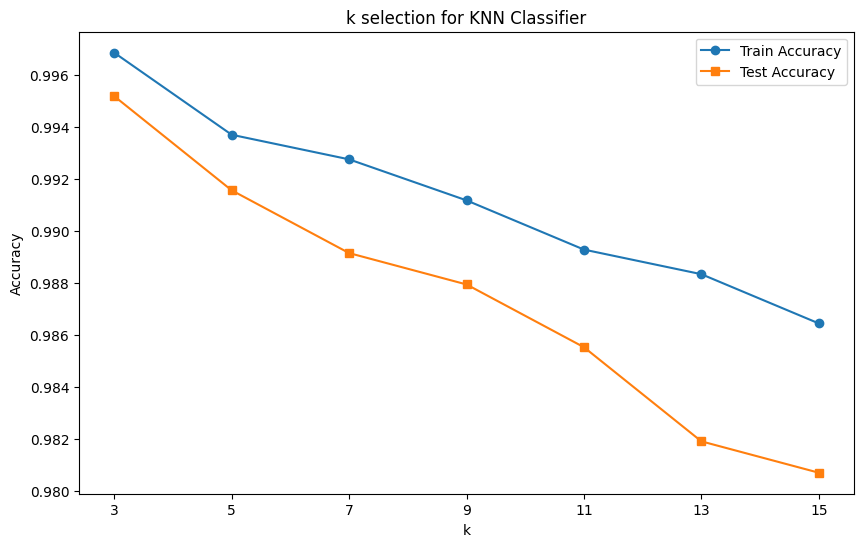

In [240]:
plt.figure(figsize=(10, 6))

plt.plot(knn_results.keys(), [x[0] for x in knn_results.values()], label="Train Accuracy", marker="o")
plt.plot(knn_results.keys(), [x[1] for x in knn_results.values()], label="Test Accuracy", marker="s")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.xticks([k for k in knn_results.keys() if k % 2 != 0])
plt.title("k selection for KNN Classifier")
plt.legend()
plt.show()

## Task 4: Reproducibility and concise reporting (2 marks)

In [239]:
# Summary of the results

results = pd.DataFrame({
    "Models": ["DT-Gini", "DT-informationGain", "DT-InformationGainRatio", "KNN"],
    "Train Accuracy": [gini_train_acc, IF_train_acc, gr_train_acc, best_k_train_acc],
    "Test Accuracy": [gini_test_acc, IF_test_acc, gr_test_acc, best_k_test_acc]
})

results


,Models,Train Accuracy,Test Accuracy
0,DT-Gini,99.6531,99.0350
1,DT-informationGain,99.5900,98.7937
2,DT-InformationGainRatio,91.9899,80.9409
3,KNN,99.6846,99.5175
